# Candlestick Accuracy Boost Notebook

This notebook wraps a cleaner training module for your dataset.

Before you run it on Kaggle, switch the notebook accelerator to `GPU`.

What it changes compared with the earlier notebooks:
- removes `RandomHorizontalFlip`, because it reverses time order
- rebuilds splits from `labels.csv` with a purge gap to stop `19/20`-candle overlap across boundaries
- crops chart content before resize so the model sees less empty white space
- uses stronger ResNet and DeiT fine-tuning defaults for Kaggle
- records both accuracy and macro F1


In [1]:
!pip install -q transformers

In [8]:
import sys
sys.path.insert(1, '/kaggle/input/datasets/romromkankane/resnet-and-vit-functions')

import kaggle_resnet_vit_boost

In [9]:
from kaggle_resnet_vit_boost import *

In [10]:
base_cfg = TrainConfig()
metadata = load_metadata(base_cfg)
split_df = build_purged_time_split(metadata, gap=base_cfg.purge_gap)
report = dataset_diagnostics(split_df, base_cfg)
report["image_stats"] = get_image_stats(split_df)
print_diagnostics(report)

{
  "rows": 16967,
  "stocks": 50,
  "label_counts": {
    "down": 7888,
    "up": 5599,
    "neutral": 3480
  },
  "purge_gap": 19,
  "window_size": 20,
  "boundary_overlap_if_unpurged": 19,
  "stock_days_with_multiple_labels_pct": 39.06,
  "adjacent_window_flip_rate_pct": 18.81,
  "split_counts": {
    "test": {
      "down": 507,
      "neutral": 128,
      "up": 349
    },
    "train": {
      "down": 5875,
      "neutral": 2957,
      "up": 4360
    },
    "val": {
      "down": 1506,
      "neutral": 395,
      "up": 890
    }
  },
  "image_stats": {
    "white_fraction_min": 0.7407,
    "white_fraction_median": 0.8501,
    "white_fraction_max": 0.9222
  }
}


## ResNet50 Run

Start with this one. It is usually the safest choice for your current dataset size and the thin local geometry of candles.


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 183MB/s] 
/kaggle/input/datasets/romromkankane/resnet-and-vit-functions/kaggle_resnet_vit_boost.py:527: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=bool(config.amp and device.type == "cuda"))
/kaggle/input/datasets/romromkankane/resnet-and-vit-functions/kaggle_resnet_vit_boost.py:459: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):
/kaggle/input/datasets/romromkankane/resnet-and-vit-functions/kaggle_resnet_vit_boost.py:459: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):


[01/14] train_acc=0.4522 val_acc=0.3741 train_f1=0.4518 val_f1=0.2981 lr=4.94e-05


/kaggle/input/datasets/romromkankane/resnet-and-vit-functions/kaggle_resnet_vit_boost.py:459: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):
/kaggle/input/datasets/romromkankane/resnet-and-vit-functions/kaggle_resnet_vit_boost.py:459: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):


[02/14] train_acc=0.7290 val_acc=0.4396 train_f1=0.7288 val_f1=0.3396 lr=4.76e-05


...

[08/14] train_acc=0.9899 val_acc=0.4378 train_f1=0.9899 val_f1=0.3594 lr=2.00e-05


/kaggle/input/datasets/romromkankane/resnet-and-vit-functions/kaggle_resnet_vit_boost.py:459: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):
/kaggle/input/datasets/romromkankane/resnet-and-vit-functions/kaggle_resnet_vit_boost.py:459: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):


[09/14] train_acc=0.9949 val_acc=0.4031 train_f1=0.9949 val_f1=0.3487 lr=1.49e-05
Early stopping at epoch 9


/kaggle/input/datasets/romromkankane/resnet-and-vit-functions/kaggle_resnet_vit_boost.py:499: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):
/kaggle/input/datasets/romromkankane/resnet-and-vit-functions/kaggle_resnet_vit_boost.py:499: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):


Saved summary to /kaggle/working/candlestick_runs/resnet50_320px_gap19_summary.json


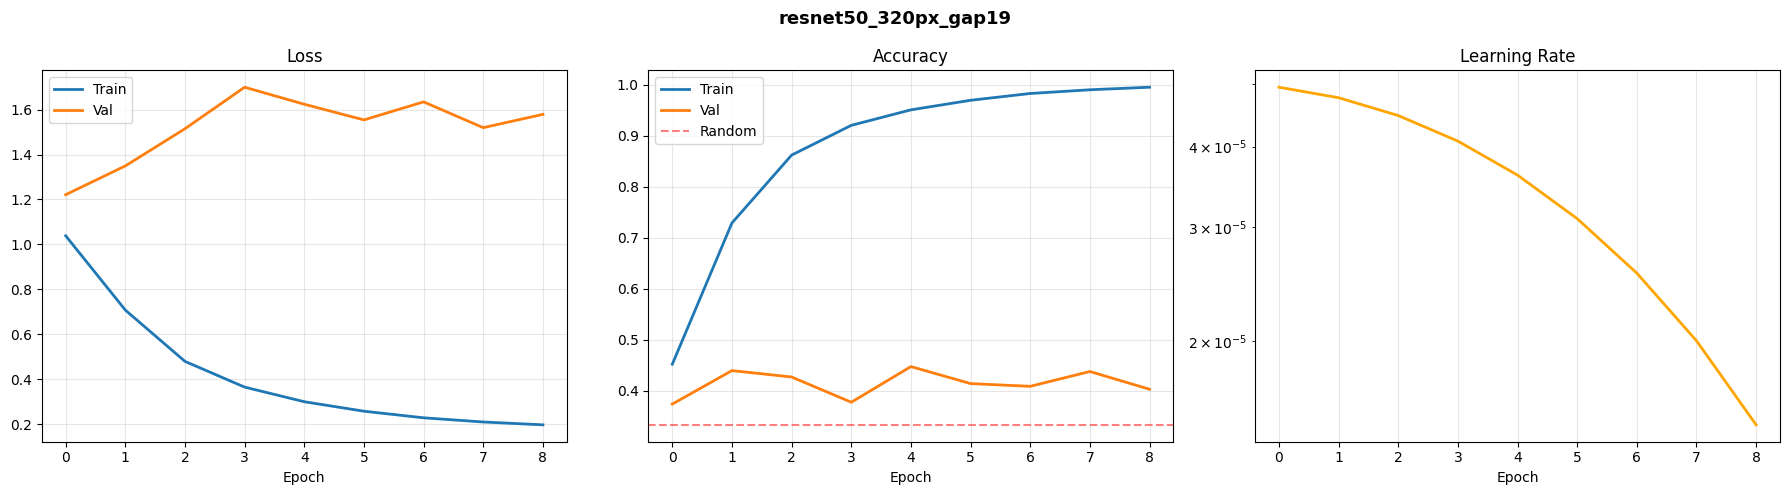

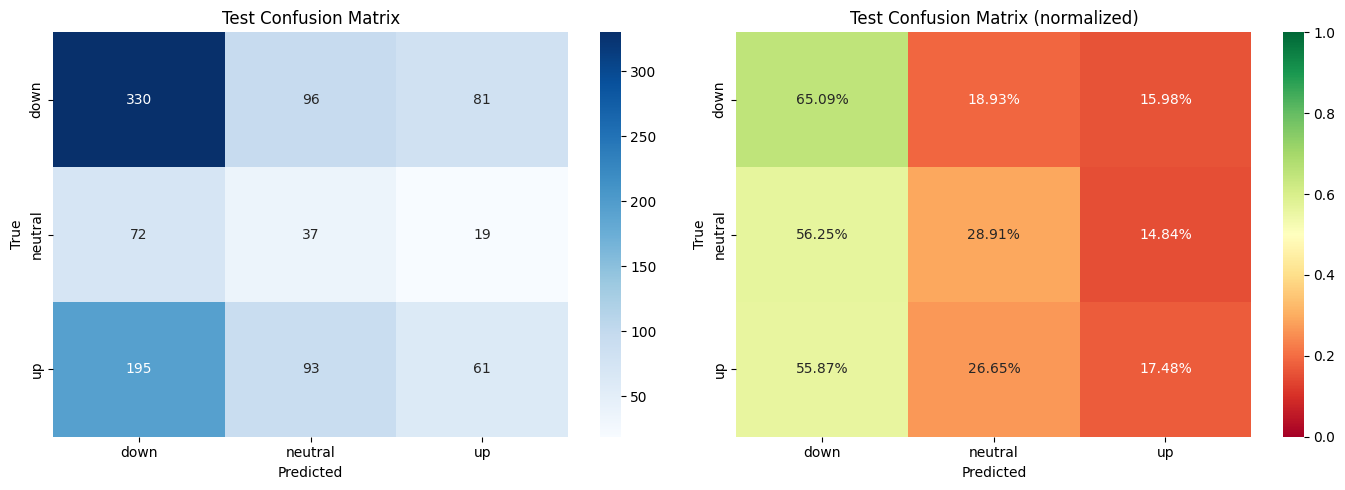

,precision,recall,f1-score,support
down,0.552764,0.650888,0.597826,507.000000
neutral,0.163717,0.289062,0.209040,128.000000
up,0.378882,0.174785,0.239216,349.000000
accuracy,0.434959,0.434959,0.434959,0.434959
macro avg,0.365121,0.371578,0.348694,984.000000
weighted avg,0.440485,0.434959,0.420062,984.000000


In [11]:
resnet_cfg = TrainConfig(
    model_family="resnet50",
    image_size=320,
    batch_size=32,
    epochs=14,
    patience=4,
    lr_backbone=5e-5,
    lr_head=3e-4,
)
resnet_report = train_model(resnet_cfg)
plot_history(resnet_report)
plot_confusion(resnet_report)
pd.DataFrame(resnet_report["test"]["classification_report"]).T

## DeiT Run

DeiT is a more data-efficient ViT family than the vanilla ViT you used before. If GPU memory is tight, lower `batch_size` to `8`.


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


pytorch_model.bin:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

...

[11/12] train_acc=0.9995 val_acc=0.4278 train_f1=0.9995 val_f1=0.3357 lr=1.49e-06


/kaggle/input/datasets/romromkankane/resnet-and-vit-functions/kaggle_resnet_vit_boost.py:459: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):
/kaggle/input/datasets/romromkankane/resnet-and-vit-functions/kaggle_resnet_vit_boost.py:459: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):


[12/12] train_acc=0.9999 val_acc=0.4310 train_f1=0.9999 val_f1=0.3391 lr=1.00e-06


/kaggle/input/datasets/romromkankane/resnet-and-vit-functions/kaggle_resnet_vit_boost.py:499: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):
/kaggle/input/datasets/romromkankane/resnet-and-vit-functions/kaggle_resnet_vit_boost.py:499: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):


Saved summary to /kaggle/working/candlestick_runs/deit_224px_gap19_summary.json


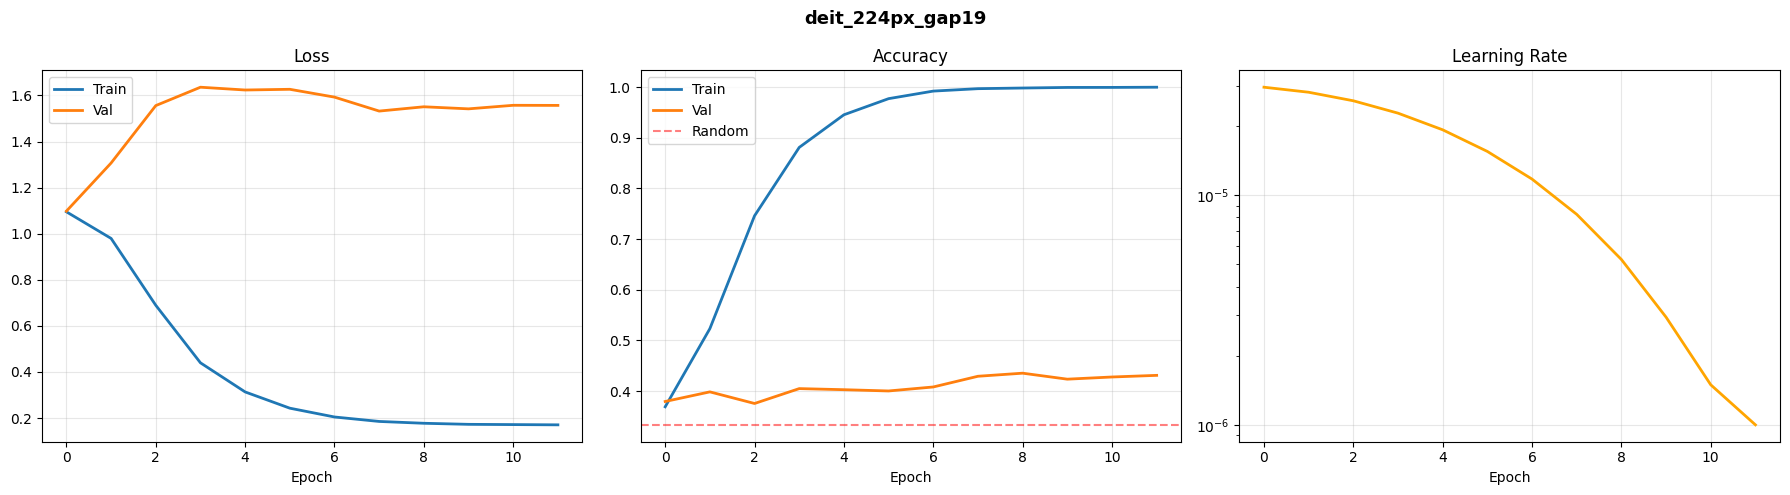

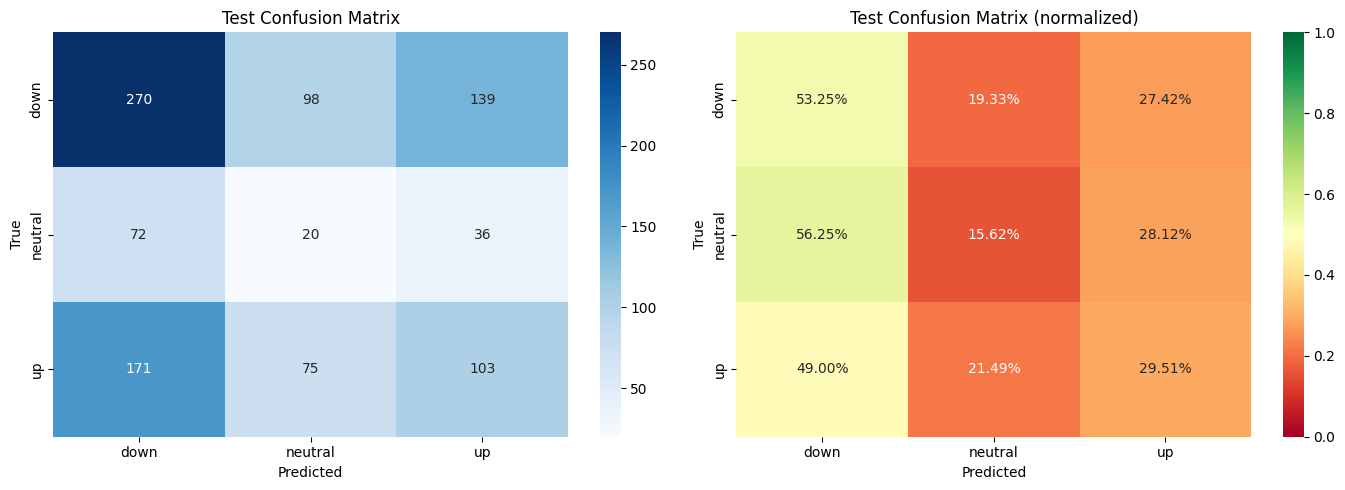

,precision,recall,f1-score,support
down,0.526316,0.532544,0.529412,507.00000
neutral,0.103627,0.156250,0.124611,128.00000
up,0.370504,0.295129,0.328549,349.00000
accuracy,0.399390,0.399390,0.399390,0.39939
macro avg,0.333482,0.327974,0.327524,984.00000
weighted avg,0.416069,0.399390,0.405514,984.00000


In [12]:
deit_cfg = TrainConfig(
    model_family="deit",
    vit_checkpoint="facebook/deit-base-patch16-224",
    image_size=224,
    batch_size=16,
    epochs=12,
    patience=4,
    lr_backbone=3e-5,
    lr_head=2e-4,
)
deit_report = train_model(deit_cfg)
plot_history(deit_report)
plot_confusion(deit_report)
pd.DataFrame(deit_report["test"]["classification_report"]).T

## Compare Runs

In [13]:
comparison = compare_reports([resnet_report, deit_report])
comparison

,run_name,val_acc,val_f1,test_acc,test_f1
0,resnet50_320px_gap19,0.447510,0.343416,0.434959,0.348694
1,deit_224px_gap19,0.435328,0.343090,0.399390,0.327524
